<h1> Epoch plots </h1>
<h3> Plots validation metrics as epoch time series for a given experiment </h3>

In [4]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import sys
import os

In [5]:
def parse_logs(dir_path):

    '''extracts specific info for a log file, used for analysis of training'''
    parent_dir = os.path.dirname(os.getcwd())
    


    with open(os.path.join(parent_dir,'results', dir_path, 'run.log'), 'r') as f:
        logs = f.read()


    log_lines = logs.strip().split('\n')
    log_messages = [x.split('|')[2] for x in log_lines]

    folds = {}
    for msg in log_messages:

        if 'training fold' in msg:
            # update fold and int a new dict for the fold
            fold = int(msg.split('training fold')[1].strip())
            folds[fold] = {
                'train_loss': []
                , 'concept_loss': []
                , 'task_loss': []
                , 'val_loss': []
                , 'val_c_index': []}
        
        elif 'val c-index (total sample):' in msg:
            val = msg.split('val c-index (total sample):')[1].strip()
            folds[fold]['val_c_index'].append(float(val))

        elif 'val loss (mean of batches):' in msg:
            val = msg.split('val loss (mean of batches):')[1].strip()
            folds[fold]['val_loss'].append(float(val))

        elif 'train total loss:' in msg:
            val = msg.split('train total loss:')[1].strip()
            folds[fold]['train_loss'].append(float(val))

        elif 'train concept loss:' in msg:
            val = msg.split('train concept loss:')[1].strip()
            folds[fold]['concept_loss'].append(float(val))

        elif 'train task loss:' in msg:
            val = msg.split('train task loss:')[1].strip()
            folds[fold]['task_loss'].append(float(val))


    return folds



In [6]:
def make_df(json_data):

    '''turn the json into a df'''

    data = []
    columns = []

    for xp in json_data.keys():
        for fold in json_data[xp].keys():
            for metric in json_data[xp][fold].keys():
                # print(f"{xp} {fold} {metric}")
                # print(res[xp][fold][metric])
                data.append(json_data[xp][fold][metric])
                columns.append((xp,fold,metric))

    df = pd.DataFrame(data).T
    df.columns =columns=pd.MultiIndex.from_tuples(columns)

    return df

In [7]:
def plot_epochs(df,filename):

    '''visualise the runs'''

    metric = 'val_c_index'

    cols = [x for x in df.columns if x[2] == metric]

    df_chart = df[cols].copy()

    df_chart[('total','total','max')] = df_chart.max(axis=1)
    df_chart[('total','total','min')] = df_chart.min(axis=1)
    df_chart[('total','total','mean')] = df_chart.mean(axis=1)
    df_chart[('total','total','std')] = df_chart.std(axis=1)
    df_chart[('total','total','median')] = df_chart.median(axis=1)

    df_chart[('total','total','mean+std')] = df_chart[('total','total','mean')] + df_chart[('total','total','std')]
    df_chart[('total','total','mean-std')] = df_chart[('total','total','mean')] - df_chart[('total','total','std')]

    fig, ax = plt.subplots(1,2,figsize=(9,4))

    ax[0].plot(df_chart.index,df_chart[('total','total','median')],label='median',linestyle='--',color='black')
    ax[0].fill_between(df_chart.index,df_chart[('total','total','mean-std')],df_chart[('total','total','mean+std')],alpha=0.2,label='1 STD')

    ax[0].legend(loc='lower right')

    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('C-Index')
    ax[0].set_title(f'Validation C-Index over epochs',loc='left')

    ax[0].set_yticks(np.linspace(0.5,0.75,6))
    ax[0].yaxis.set_minor_locator(MultipleLocator(0.01))
    ax[0].xaxis.set_minor_locator(MultipleLocator(1))

    # ax[0].set_xticks(np.linspace(0,30,6))

    ax[0].set_ylim([0.5,0.75])
    ax[0].grid(which="major", alpha=0.9)
    ax[0].grid(which="minor", alpha=0.2,linestyle='--')

    metric = 'val_loss'

    cols = [x for x in df.columns if x[2] == metric]

    df_chart = df[cols].copy()

    df_chart[('total','total','max')] = df_chart.max(axis=1)
    df_chart[('total','total','min')] = df_chart.min(axis=1)
    df_chart[('total','total','mean')] = df_chart.mean(axis=1)
    df_chart[('total','total','std')] = df_chart.std(axis=1)
    df_chart[('total','total','median')] = df_chart.median(axis=1)

    df_chart[('total','total','mean+std')] = df_chart[('total','total','mean')] + df_chart[('total','total','std')]
    df_chart[('total','total','mean-std')] = df_chart[('total','total','mean')] - df_chart[('total','total','std')]

    ax[1].plot(df_chart.index,df_chart[('total','total','mean')],label='validation loss',color='blue')
    ax[1].fill_between(df_chart.index,df_chart[('total','total','mean-std')],df_chart[('total','total','mean+std')],alpha=0.2)

    metric = 'train_loss'

    cols = [x for x in df.columns if x[2] == metric]

    df_chart = df[cols].copy()

    df_chart[('total','total','max')] = df_chart.max(axis=1)
    df_chart[('total','total','min')] = df_chart.min(axis=1)
    df_chart[('total','total','mean')] = df_chart.mean(axis=1)
    df_chart[('total','total','std')] = df_chart.std(axis=1)
    df_chart[('total','total','median')] = df_chart.median(axis=1)

    df_chart[('total','total','mean+std')] = df_chart[('total','total','mean')] + df_chart[('total','total','std')]
    df_chart[('total','total','mean-std')] = df_chart[('total','total','mean')] - df_chart[('total','total','std')]

    ax[1].plot(df_chart.index,df_chart[('total','total','mean')],label='train loss',color='red')
    ax[1].fill_between(df_chart.index,df_chart[('total','total','mean-std')],df_chart[('total','total','mean+std')],alpha=0.2)

    ax[1].legend(loc='upper left')

    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Loss')
    ax[1].set_title(f'Loss over epochs',loc='left')


    ax[1].grid(which="major", alpha=0.9)
    ax[1].grid(which="minor", alpha=0.2,linestyle='--')


    plt.savefig(filename, bbox_inches="tight")
    plt.show()


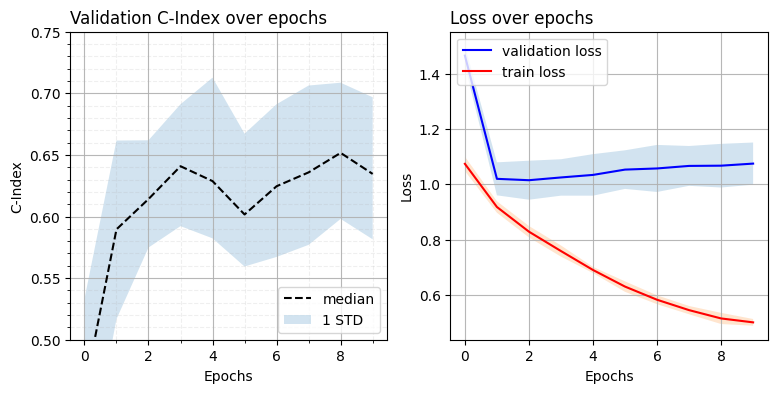

In [8]:
run_names = ['baseline_1781214199/run_1', 'baseline_1781214199/run_2']

data = {}
for run_name in run_names:
    data[run_name] =  parse_logs(run_name)

df = make_df(data)
plot_epochs(df,filename='epochs.pdf')